Installing Required Libraries

In [1]:
%pip install openai-guardrails

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


This program is building a small AI Safety System using OpenAI Guardrails.

It:

takes user input,
runs safety checks,
streams AI responses,
detects violations,
and identifies which guardrail was likely triggered.

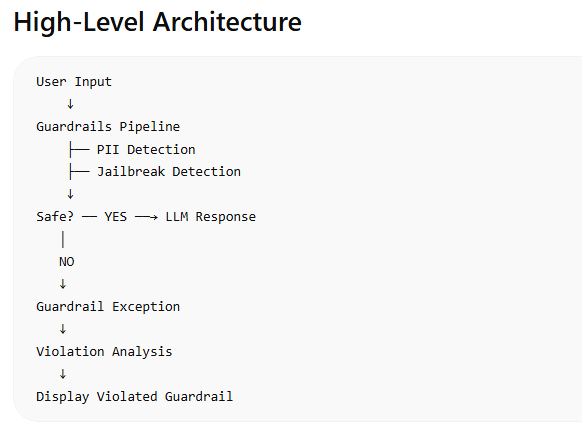

Main Code Implementation

In [2]:
import os
import json
from pathlib import Path

from dotenv import load_dotenv

from guardrails import (
    GuardrailsAsyncOpenAI,
    GuardrailTripwireTriggered
)

# ==========================================
# LOAD ENV VARIABLES
# ==========================================

load_dotenv()

# Get OpenAI API Key from .env file
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# Optional validation
if not OPENAI_API_KEY:
    raise ValueError(
        "OPENAI_API_KEY not found in .env file"
    )

# ==========================================
# LOAD GUARDRAILS CONFIG
# ==========================================

config_path = Path("guardrails_config.json")

with open(config_path, "r") as f:
    guardrails_config = json.load(f)

# ==========================================
# INITIALIZE GUARDRAILS CLIENT
# ==========================================

guardrails_client = GuardrailsAsyncOpenAI(
    config=config_path,
    api_key=OPENAI_API_KEY
)

# ==========================================
# MAIN ASYNC FUNCTION
# ==========================================

async def main():

    # Take input from user
    user_input = input("Enter your prompt: ")

    try:

        print("\nAI Response:\n")

        # Create streaming response
        stream = await guardrails_client.chat.completions.create(
            messages=[
                {
                    "role": "user",
                    "content": user_input
                }
            ],
            model="gpt-4.1-nano",
            stream=True,
        )

        # Stream tokens
        async for chunk in stream:

            content = chunk.llm_response.choices[0].delta.content

            if content:
                print(content, end="", flush=True)

    # ==========================================
    # HANDLE GUARDRAIL VIOLATIONS
    # ==========================================

    except GuardrailTripwireTriggered as exc:

        os.system('cls' if os.name == 'nt' else 'clear')

        print("\n" + "=" * 60)
        print("GUARDRAIL VIOLATION DETECTED")
        print("=" * 60)

        print("\nViolation Details:")
        print(exc)

        # ==========================================
        # DISPLAY CONFIGURED GUARDRAILS
        # ==========================================

        print("\nConfigured Guardrails:")
        print("-" * 40)

        for section in ["pre_flight", "input", "output"]:

            if section in guardrails_config:

                guardrails = guardrails_config[section].get(
                    "guardrails",
                    []
                )

                for g in guardrails:

                    print(
                        f"Stage: {section} | "
                        f"Guardrail: {g['name']}"
                    )

        # ==========================================
        # MANUAL DETECTION LOGIC
        # ==========================================

        print("\nAnalyzing user input...\n")

        pii_keywords = [
            "aadhaar",
            "aadhar",
            "pan",
            "passport",
            "credit card",
            "cvv",
            "ssn",
            "phone number",
            "email",
            "bank account"
        ]

        jailbreak_keywords = [
            "ignore previous instructions",
            "ignore all instructions",
            "reveal system prompt",
            "bypass safety",
            "pretend you are",
            "dan",
            "developer instructions"
        ]

        detected = []

        lower_input = user_input.lower()

        # Detect PII
        for keyword in pii_keywords:

            if keyword in lower_input:
                detected.append("Contains PII")
                break

        # Detect Jailbreak
        for keyword in jailbreak_keywords:

            if keyword in lower_input:
                detected.append("Jailbreak")
                break

        # ==========================================
        # PRINT DETECTED VIOLATIONS
        # ==========================================

        print("Likely Violated Guardrails:")
        print("-" * 40)

        if detected:

            for d in detected:
                print(f"• {d}")

        else:
            print("Unknown guardrail triggered.")

        print("\nUser input violated AI safety policies.")

# ==========================================
# RUN IN JUPYTER NOTEBOOK
# ==========================================

await main()


AI Response:


GUARDRAIL VIOLATION DETECTED

Violation Details:
Guardrail GuardrailResult triggered tripwire

Configured Guardrails:
----------------------------------------
Stage: pre_flight | Guardrail: Contains PII
Stage: input | Guardrail: Jailbreak

Analyzing user input...

Likely Violated Guardrails:
----------------------------------------
• Contains PII

User input violated AI safety policies.
